<a href="https://colab.research.google.com/github/rajkumarb5285/-software-using-py/blob/main/smartcrop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("atharvaingle/crop-recommendation-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'crop-recommendation-dataset' dataset.
Path to dataset files: /kaggle/input/crop-recommendation-dataset


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [ ]:
import os

# The 'path' variable from the kagglehub download holds the directory
# where the dataset files are located.
csv_file_path = os.path.join(path, "Crop_recommendation.csv")

df = pd.read_csv(csv_file_path)

print(df.head())

print(df.shape)

    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice
(2200, 8)


In [ ]:
X = df.drop(
    "label",
    axis=1
)

y = df["label"]

In [ ]:
encoder = LabelEncoder()

y = encoder.fit_transform(y)

print(
    encoder.classes_
)

['apple' 'banana' 'blackgram' 'chickpea' 'coconut' 'coffee' 'cotton'
 'grapes' 'jute' 'kidneybeans' 'lentil' 'maize' 'mango' 'mothbeans'
 'mungbean' 'muskmelon' 'orange' 'papaya' 'pigeonpeas' 'pomegranate'
 'rice' 'watermelon']


In [ ]:
y = to_categorical(y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)

In [ ]:
model = Sequential()

model.add(
    Dense(
        128,
        activation='relu',
        input_shape=(7,)
    )
)

model.add(
    Dropout(0.3)
)

model.add(
    Dense(
        64,
        activation='relu'
    )
)

model.add(
    Dropout(0.3)
)

model.add(
    Dense(
        32,
        activation='relu'
    )
)

model.add(
    Dense(
        22,
        activation='softmax'
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 22)             │           726 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,086 (47.21 KB)

 Trainable params: 12,086 (47.21 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.1420 - loss: 2.9525 - val_accuracy: 0.3977 - val_loss: 2.6549
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3295 - loss: 2.4533 - val_accuracy: 0.5881 - val_loss: 2.0023
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4922 - loss: 1.7864 - val_accuracy: 0.6932 - val_loss: 1.2290
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6335 - loss: 1.1787 - val_accuracy: 0.8381 - val_loss: 0.7205
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7053 - loss: 0.8575 - val_accuracy: 0.8892 - val_loss: 0.4966
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7734 - loss: 0.6854 - val_accuracy: 0.8750 - val_loss: 0.4072
Epoch 7/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7912 - loss: 0.5781 - val_accuracy: 0.8892 - val_loss: 0.3417
Epoch 8/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8288 - loss: 0.5031 - val_accuracy: 0.9062 - v

In [ ]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print(
    "Test Accuracy:",
    accuracy
)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9659 - loss: 0.0968  
Test Accuracy: 0.9659090638160706


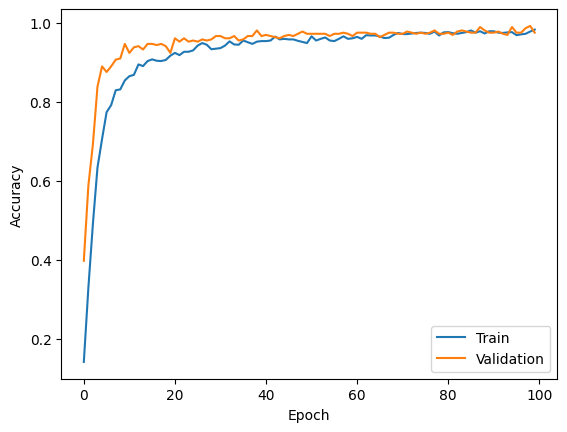

In [ ]:
plt.plot(
    history.history['accuracy']
)

plt.plot(
    history.history['val_accuracy']
)

plt.legend(
    ['Train', 'Validation']
)

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.show()

In [ ]:
model.save(
    "crop_ann_model.h5"
)

In [ ]:
import pickle

pickle.dump(
    scaler,
    open(
        "scaler.pkl",
        "wb"
    )
)

pickle.dump(
    encoder,
    open(
        "label_encoder.pkl",
        "wb"
    )
)

In [ ]:
sample = np.array([
    [90,42,43,21,82,6.5,203]
])

sample = scaler.transform(
    sample
)

pred = model.predict(
    sample
)

pred_class = np.argmax(
    pred
)

crop = encoder.inverse_transform(
    [pred_class]
)

print(
    "Recommended Crop:",
    crop[0]
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Recommended Crop: rice
